In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# from DataCollapse import *
from src.fss.data_collapse import *


# Generate pseudo data

In [3]:
def generate_pseudo_data(pc=0.5,p_list=np.round(np.linspace(0.45,.55,11),2),nu=1,L_list=np.arange(10,20,2),beta=0.5, f=lambda x: (1-x)**(1/2),seed=0, epsilon=0.01,N=100):
    """Generate pseudo data following y~L^{-beta/nu} f[(p-p_c)L^{1/nu}] + epsilon, where epsilon is a random noise, N is the sample size"""
    rng=np.random.default_rng(seed)
    data_dict={(p,L): L**(-beta/nu)*f((p-pc)* L **(1/nu))+ rng.normal(0,epsilon,N) for L in L_list for p in p_list}
    index = pd.MultiIndex.from_tuples([key for key in data_dict.keys() if key!='fn'], names=['p','L'])
    df = pd.DataFrame({'observations': data_dict.values()}, index=index)
    return df
    

In [4]:
# Generate psudo data with p_c=0.5, nu=1, beta=0.5
df=generate_pseudo_data(pc=0.5,nu=1,beta=0.5)

In [5]:
df.head()

,,observations
p,L,
0.45,10,"[0.3885556368316756, 0.38597728598782866, 0.39..."
0.46,10,"[0.3791925671761428, 0.3840628690102522, 0.372..."
0.47,10,"[0.35391977556335846, 0.35442094906025867, 0.3..."
0.48,10,"[0.3584427510549405, 0.35278089387003736, 0.35..."
0.49,10,"[0.328058077325631, 0.3374978203093675, 0.3172..."


In [6]:
df['estimator']=df['observations'].apply(np.mean)
df['standard_error']=df['observations'].apply(lambda x: np.std(x)/np.sqrt(len(x)))
df[['estimator','standard_error']].head()

,,estimator,standard_error
p,L,,
0.45,10,0.388109,0.000962
0.46,10,0.373660,0.000956
0.47,10,0.359175,0.001116
0.48,10,0.346020,0.000924
0.49,10,0.331783,0.001084


## Load data

In [7]:
dc=DataCollapse(df, p_='p',L_='L',params={},p_range=[0.45,0.55],)

## Plot the raw data

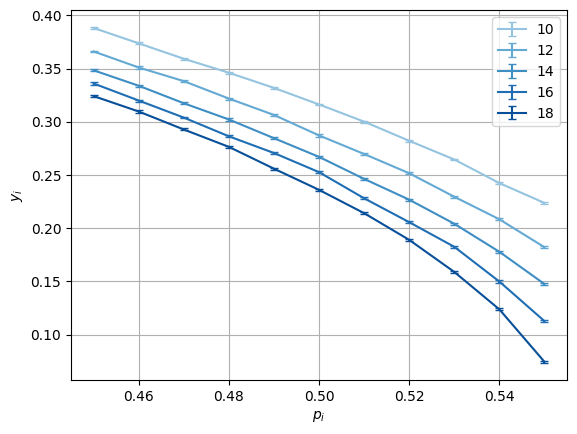

In [8]:
dc.plot_data_collapse(raw=True, errorbar=True)

## Finite size scaling

In [33]:
dc.datacollapse(p_c=0.505,nu=1.3,beta=0.0,p_c_vary=True,beta_vary=True,nu_vary=True)

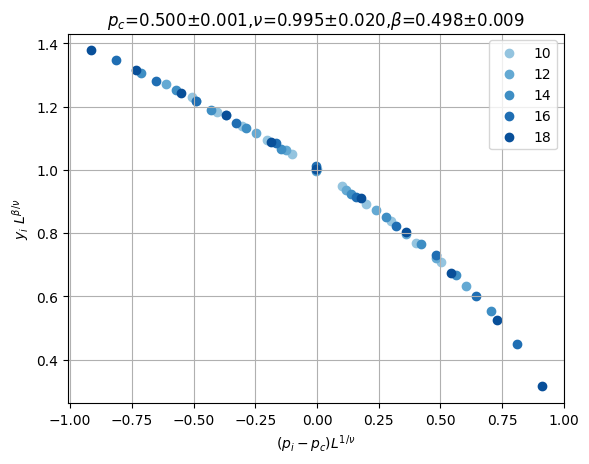

In [17]:
dc.plot_data_collapse()

p_c=0.4763, nu=1.3158, chi2=1.1200
p_c error=(0.4657, 0.4974), nu error=(1.0560, 1.4876)


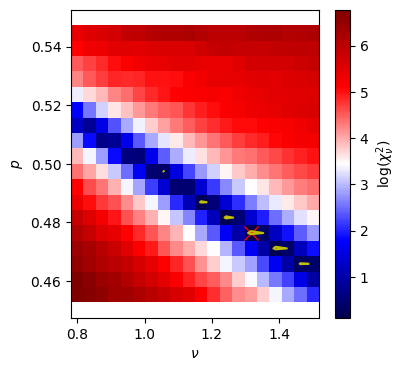

In [24]:
result = dc.parameter_sweep(
    p_c=np.linspace(0.45, 0.55, 20),
    nu=np.linspace(0.8, 1.5, 20),
    beta=0.5,
    n_jobs=-1,  # use all cores
    backend='threading',  # multiprocessing
)

# Sweep parameters

In [35]:
df=generate_pseudo_data(pc=0.5,nu=1,beta=0.0, epsilon=0.1)

In [36]:
dc=DataCollapse(df, p_='p',L_='L',params={},p_range=[0.45,0.55],)

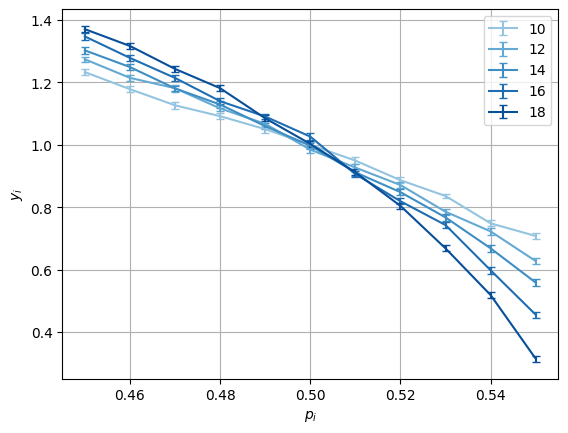

In [37]:
dc.plot_data_collapse(raw=True, errorbar=True)

p_c=0.5011, nu=0.9868, chi2=0.9882
p_c error=(0.4977, 0.5032), nu error=(0.9335, 1.1107)


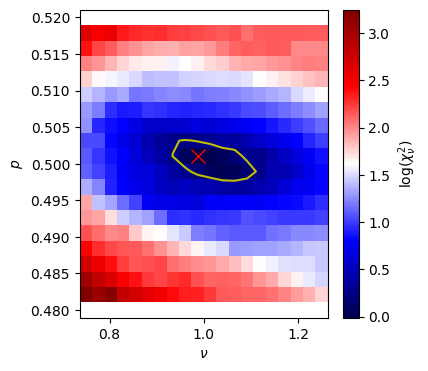

In [44]:
result = dc.parameter_sweep(
    p_c=np.linspace(0.48, 0.52, 20),
    nu=np.linspace(0.75, 1.25, 20),
    beta=0,
    n_jobs=-1,  # use all cores
    backend='threading',  # multiprocessing
)

In [39]:
dc.datacollapse(p_c=0.5026,nu=0.9474,beta=0.0,p_c_vary=True,beta_vary=True,nu_vary=True)

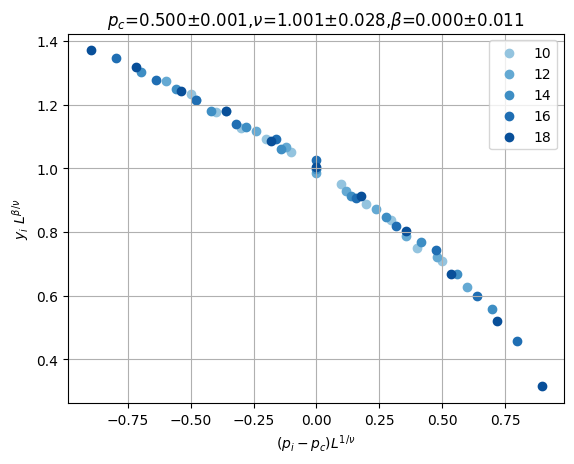

In [40]:
dc.plot_data_collapse()

## Load data with `estimator='manual'` 

In [41]:
dc=DataCollapse(df, p_='p',L_='L',params={},p_range=[0.45,0.55],estimator='manual',)

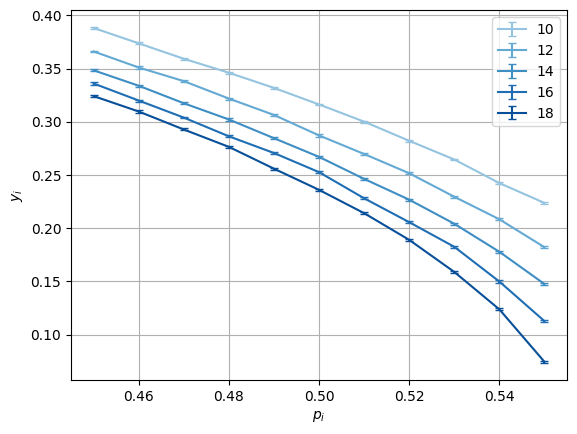

In [42]:
dc.plot_data_collapse(raw=True, errorbar=True)

# Generate data with drifting

In [3]:
import numpy as np, pandas as pd

# Generate dummy data with known parameters
# O = a00 + a10*x + (a01 + a11*x)*L^{-y}
# where x = (p - p_c) * L^{1/nu}
p_c_true, nu_true, y_true = 0.5, 1.3, 1.0
a_true = np.array([[1.0, 0.5],    # a00, a01
                   [0.3, 0.2]])   # a10, a11 (n1=1, linear)

rng = np.random.default_rng(0)
p_list = np.round(np.linspace(0.45, 0.55, 11), 2)
L_list = np.array([8, 16, 32, 64])  # wide range so L^{-y} varies 8x

data = {}
for L in L_list:
    for p in p_list:
        x = (p - p_c_true) * L ** (1 / nu_true)
        ir = L ** (-y_true)
        y_mean = sum(a_true[j1, j2] * x**j1 * ir**j2
                     for j1 in range(2) for j2 in range(2))
        data[(p, L)] = rng.normal(y_mean, 0.01, 100)

index = pd.MultiIndex.from_tuples(list(data.keys()), names=['p', 'L'])
df = pd.DataFrame({'observations': list(data.values())}, index=index)


In [4]:
dc=DataCollapse(df, p_='p',L_='L',params={},p_range=[0.45,0.55],)

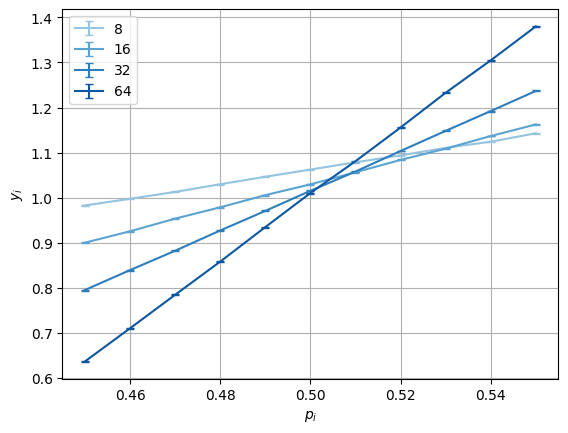

In [5]:
dc.plot_data_collapse(raw=True, errorbar=True)

## Verify with (n1, n2) = (2, 1)

In [6]:
# Fit with corrections (n1=1, n2=1 matches the true model)
dc = DataCollapse(df, p_='p', L_='L', params={}, p_range=[0.45, 0.55])
res = dc.datacollapse_with_drift_GLS(n1=1, n2=1, p_c=0.5, nu=1.0, y=1.0)
print(res.params)  # should recover p_c≈0.5, nu≈1.3, y≈1.0


Parameters([('p_c', <Parameter 'p_c', value=np.float64(0.4994771683588808) +/- 0.000519, bounds=[0:1]>), ('nu', <Parameter 'nu', value=np.float64(1.3004515579166385) +/- 0.0117, bounds=[0:2]>), ('y', <Parameter 'y', value=np.float64(0.9171365484630931) +/- 0.0972, bounds=[0:5]>), ('beta', <Parameter 'beta', value=0 (fixed), bounds=[0:2]>)])


In [7]:
res.params

name,value,standard error,relative error,initial value,min,max,vary
p_c,0.49947717,5.1872e-04,(0.10%),0.5,0.00000000,1.00000000,True
nu,1.30045156,0.01171366,(0.90%),1.0,0.00000000,2.00000000,True
y,0.91713655,0.09719945,(10.60%),1.0,0.00000000,5.00000000,True
beta,0.00000000,0.00000000,,0,0.00000000,2.00000000,False


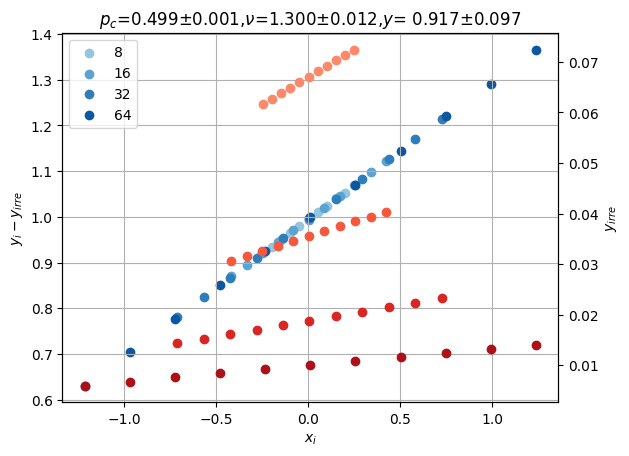

In [8]:
dc.plot_data_collapse(drift=True, driftcollapse=True)

## Model selection via grid search

100%|██████████| 9/9 [00:00<00:00, 156.43it/s]


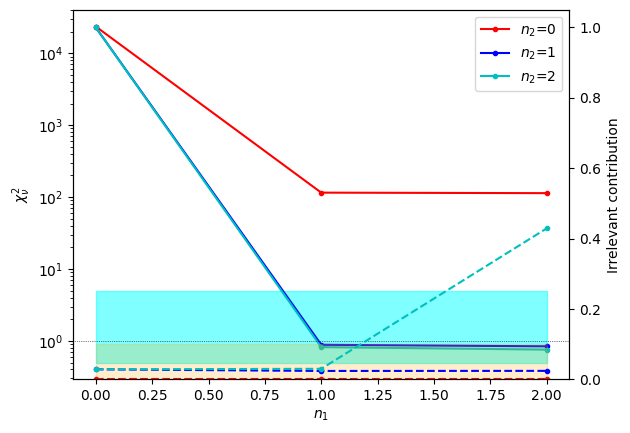

In [10]:
# Grid search for optimal (n1, n2)
model_dict = grid_search(
    n1_list=range(0, 3), n2_list=range(0, 3),
    p_c=0.5, nu=1.0, y=1.0,
    p_c_range=(0.45, 0.55), nu_range=(0.5, 2.0),
    df=df, p_='p', L_='L', params={}, p_range=[0.45, 0.55]
)
plot_chi2_ratio(model_dict)

# Generate data of Berezinskii-Kosterlitz-Thouless (BKT) transition

In [61]:
def generate_bkt_data(p_c=0.892,L_0 = 1.2, Δ=-0.25, c=2.0, σ=1/2, L_vals = np.array([16, 32, 64, 128, 256]),
    p_vals = np.linspace(0.8, 0.98, 19),
add_noise=False, noise_level=0.01, N=100, seed=0):
    
    rng = np.random.default_rng(seed)
    data_dict = {}
    
    for L in L_vals:
        for p in p_vals:
            # Calculate the BKT scaling variable x
            x = (p - p_c) * (np.log(L / L_0))**(1/σ)
            
            # Synthetic scaling function f(x)
            f_x = 1.0 / (1.0 + np.exp(c * x))
            
            # Calculate final observable O(L, p)
            O_val = (L**Δ) * f_x
            
            data_dict[(p,L)] = O_val + rng.normal(0, noise_level * abs(O_val), N)
                
    index = pd.MultiIndex.from_tuples([key for key in data_dict.keys() if key!='fn'], names=['p','L'])
    df = pd.DataFrame({'observations': list(data_dict.values())}, index=index)
    return df

## Zero scaling dim

In [82]:
df_BKT = generate_bkt_data(add_noise=True, noise_level=0.005,  Δ=-0)

In [83]:
df_BKT.head()

,,observations
p,L,
0.80,16,"[0.7751000362230895, 0.774101424085483, 0.7770..."
0.81,16,"[0.7522125678589381, 0.754039726576623, 0.7497..."
0.82,16,"[0.7219514062154104, 0.7221329198743414, 0.718..."
0.83,16,"[0.7009645747879176, 0.6989920613531175, 0.698..."
0.84,16,"[0.66649346776874, 0.6696449108201395, 0.66289..."


In [84]:
dc_BKT=DataCollapse(df_BKT, p_='p',L_='L',params={},p_range=[0.85,0.94],)

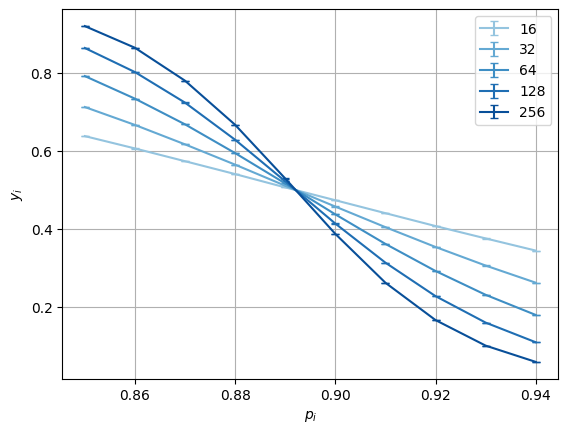

In [85]:
dc_BKT.plot_data_collapse(raw=True, errorbar=True)

### Power-law ansatz
First, try the conventional power-law collapse $O \sim L^{-\beta/\nu} f((p-p_c) L^{1/\nu})$ on BKT data.
The poor $\chi^2$ reveals the power-law ansatz is inadequate.

p_c=0.8936, nu=2.0000, chi2=3710.7036
p_c error=(0.8911, 0.8944), nu error=(1.9551, 2.0870)


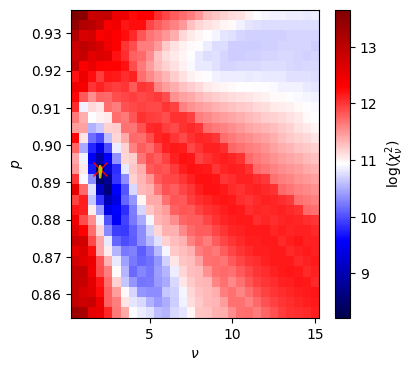

In [86]:
result = dc_BKT.parameter_sweep(
    p_c=np.linspace(0.855, 0.935, 30),
    nu=np.linspace(0.5, 15, 30),
    beta=0,
    n_jobs=-1,
    backend='threading',
    log_chi2=True,
)

In [87]:
dc_BKT.datacollapse(p_c=result['p_c'], nu=result['nu'], beta=0.0,
    p_c_vary=True, nu_vary=True, beta_vary=False,
    nan_policy='omit')
dc_BKT.res.params

name,value,standard error,relative error,initial value,min,max,vary
p_c,0.89362069,5.5275e-04,(0.06%),0.8936206896551724,0.00000000,1.00000000,True
nu,2.00000000,3.9137e-13,(0.00%),2.0,0.50000000,2.00000000,True
beta,0.00000000,0.00000000,,0.0,0.00000000,1.00000000,False


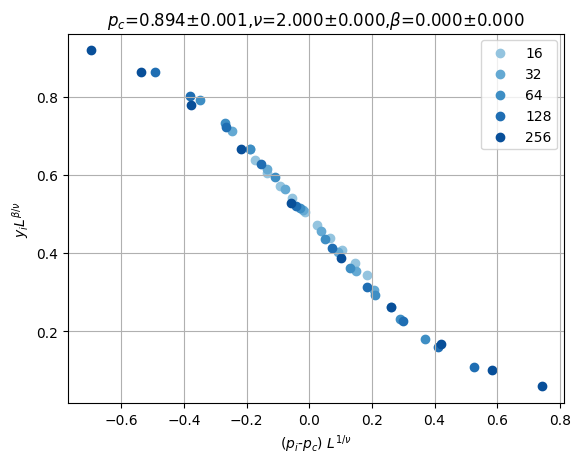

In [88]:
dc_BKT.plot_data_collapse()

In [92]:
print(f"chi^2 is {dc_BKT.res.redchi:.1f}")

chi^2 is 3872.0


### BKT ansatz
Now use the BKT scaling form $O \sim L^{\Delta} f((p-p_c) (\log L/L_0)^{1/\sigma})$.
The $\chi^2$ improves dramatically.

p_c=0.8909, sigma=0.5310, chi2=332.3743
p_c error=(0.8907, 0.8913), sigma error=(0.5012, 0.5336)


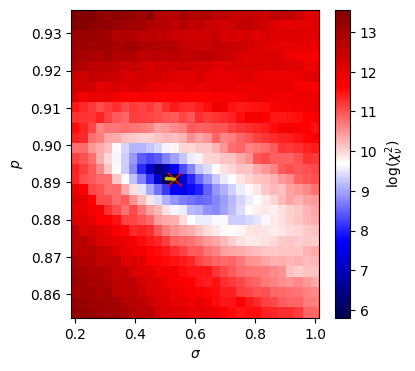

In [93]:
result_bkt = dc_BKT.parameter_sweep_bkt(
    p_c=np.linspace(0.855, 0.935, 30),
    sigma=np.linspace(0.2, 1.0, 30),
    L_0=1.2,
    delta=0.0,
    n_jobs=-1,
    backend='threading',
    log_chi2=True,
)

In [94]:
dc_BKT.datacollapse_bkt(
    p_c=result_bkt['p_c'], L_0=1.0, sigma=result_bkt['sigma'], delta=0.0,
    p_c_range=(0.85, 0.95), L_0_range=(0.01, 5.0), delta_vary=False,
    method='differential_evolution',
)
dc_BKT.res.params

name,value,initial value,min,max,vary
p_c,0.89199603,0.8908620689655172,0.85000000,0.95000000,True
L_0,1.30422808,1.0,0.01000000,5.00000000,True
sigma,0.51162528,0.5310344827586208,0.10000000,5.00000000,True
delta,0.00000000,0.0,-2.00000000,2.00000000,False


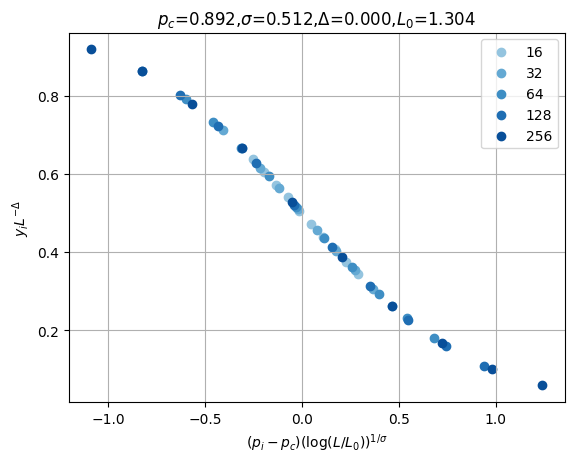

In [95]:
dc_BKT.plot_data_collapse()

## Finite scaling dim

In [71]:
df_BKT = generate_bkt_data(add_noise=True, noise_level=0.005,  Δ=-0.25)

In [72]:
df_BKT.head()

,,observations
p,L,
0.80,16,"[0.38755001811154477, 0.3870507120427415, 0.38..."
0.81,16,"[0.37610628392946904, 0.3770198632883115, 0.37..."
0.82,16,"[0.3609757031077052, 0.3610664599371707, 0.359..."
0.83,16,"[0.3504822873939588, 0.34949603067655877, 0.34..."
0.84,16,"[0.33324673388437, 0.3348224554100698, 0.33144..."


In [73]:
dc_BKT=DataCollapse(df_BKT, p_='p',L_='L',params={},p_range=[0.85,0.94],)

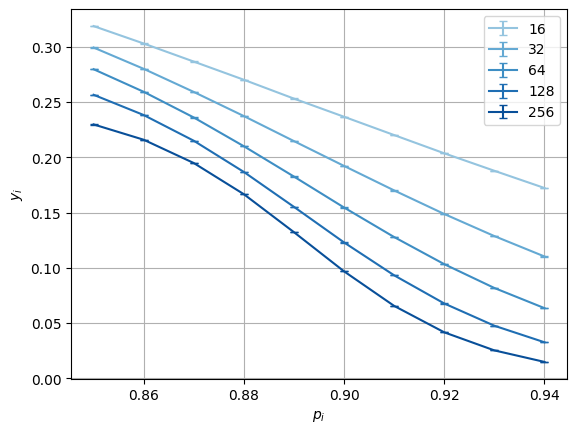

In [74]:
dc_BKT.plot_data_collapse(raw=True, errorbar=True)

### BKT parameter sweep

p_c=0.8926, sigma=0.4947, chi2=97.6571
p_c error=(0.8926, 0.8926), sigma error=(0.4937, 0.4957)


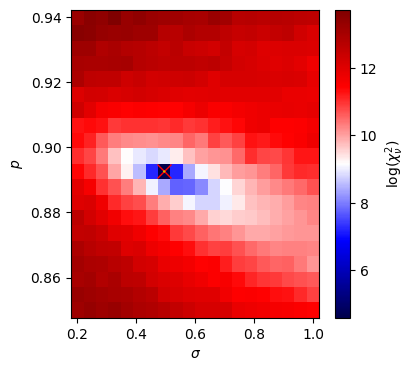

In [75]:
result = dc_BKT.parameter_sweep_bkt(
    p_c=np.linspace(0.85, 0.94, 20),
    sigma=np.linspace(0.2, 1.0, 20),
    L_0=1.2,
    delta=-0.25,
    n_jobs=-1,
    backend='threading',
)

### BKT data collapse

In [76]:
res_BKT = dc_BKT.datacollapse_bkt(
    p_c=0.9, L_0=1.0, sigma=0.5, delta=-0.2,
    p_c_range=(0.85, 0.95), L_0_range=(0.01, 5.0), delta_vary=True,
    method='differential_evolution',
)
res_BKT.params

name,value,initial value,min,max,vary
p_c,0.89237410,0.9,0.85000000,0.95000000,True
L_0,1.27632136,1.0,0.01000000,5.00000000,True
sigma,0.50614208,0.5,0.10000000,5.00000000,True
delta,-0.25275081,-0.2,-2.00000000,2.00000000,True


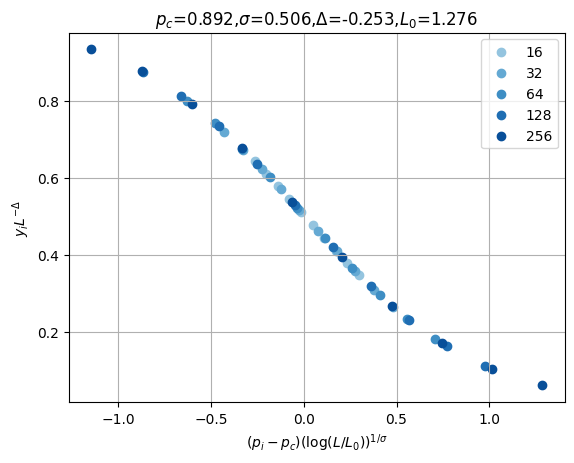

In [77]:
dc_BKT.plot_data_collapse()